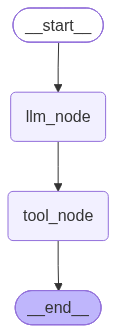

2026-09-01 19:20:42.715 | INFO     | __main__:tool_node:72 - 工具get_weather被调用,对应的 tool_call:{'name': 'get_weather', 'args': {'city': '北京'}, 'id': 'call_00_sonPfIJ7dSDI2iNq8eIy7846', 'type': 'tool_call'}


============================== -> interrupt_res <-  ==============================
================================ Human Message =================================

今天北京天气如何 
================================== Ai Message ==================================

我来为您查询北京今天的天气情况。
Tool Calls:
  get_weather (call_00_sonPfIJ7dSDI2iNq8eIy7846)
 Call ID: call_00_sonPfIJ7dSDI2iNq8eIy7846
  Args:
    city: 北京
============================== -> interrupt_info <-  ==============================
[Interrupt(value={'action': 'get_weather', 'question': '是否同意查询天气?'}, id='38e807510b5d02c1cb51e6a88c9b838a')]


2026-09-01 19:20:45.563 | INFO     | __main__:tool_node:72 - 工具get_weather被调用,对应的 tool_call:{'name': 'get_weather', 'args': {'city': '北京'}, 'id': 'call_00_sonPfIJ7dSDI2iNq8eIy7846', 'type': 'tool_call'}
2026-09-01 19:20:45.567 | INFO     | __main__:get_weather:50 - is_approved: False


============================== -> approved_res <-  ==============================
================================ Human Message =================================

今天北京天气如何 
================================== Ai Message ==================================

我来为您查询北京今天的天气情况。
Tool Calls:
  get_weather (call_00_sonPfIJ7dSDI2iNq8eIy7846)
 Call ID: call_00_sonPfIJ7dSDI2iNq8eIy7846
  Args:
    city: 北京
================================= Tool Message =================================
Name: get_weather

用户拒绝查询天气


In [4]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.runtime import Runtime
import time
from dataclasses import dataclass
from operator import add
from langchain_core.messages import ToolMessage, SystemMessage
from random import randint

from langchain_core.runnables import RunnableConfig
from langgraph.cache.memory import InMemoryCache
from langgraph.errors import GraphRecursionError
from langgraph.graph import MessagesState

from multiprocessing import resource_tracker, context

from langgraph.graph import StateGraph, START, END, MessagesState, MessageGraph
from typing import TypedDict, Literal, Sequence, Annotated, Final, Tuple
from IPython.display import display
from langchain_deepseek import ChatDeepSeek
from dotenv import load_dotenv
from langchain.tools import tool
from langgraph.managed.is_last_step import RemainingSteps
from loguru import logger
from langgraph.types import Send, Command, CachePolicy, interrupt
from langchain.messages import HumanMessage, AIMessage, SystemMessage
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    # temperature=0.7,
    extra_body={
        "thinking": {
            "type": "disabled",
        }
    }
)

@tool(parse_docstring=True)
def get_weather(city: str) -> str:
    """
    查询指定城市的当日天气

    Args:
        city:城市名称
    """
    is_approved = interrupt({
    "action": "get_weather",
    "question":"是否同意查询天气?"
    })
    logger.info("is_approved: {}", is_approved)
    if is_approved:
        return f"{city} 今天天气不错"
    else:
        return "用户拒绝查询天气"
tools_by_name = {"get_weather": get_weather}

model_with_tools = model.bind_tools([get_weather])

def llm_node(state: MessagesState) -> MessagesState:
    messages = state['messages']
    response = model_with_tools.invoke(messages)

    return {
        "messages": [response]
    }

def tool_node(state: MessagesState) -> MessagesState:
    last_msg = state['messages'][-1]
    tool_msgs = []
    for tool_call in last_msg.tool_calls:
        tool = tools_by_name[tool_call["name"]]
        logger.info("工具{}被调用,对应的 tool_call:{}",
        tool_call["name"], tool_call)
        tool_res = tool.invoke(tool_call["args"])
        tool_msg = ToolMessage(
        name = tool_call["name"],
        content = tool_res,
        tool_call_id = tool_call["id"]
        )
        tool_msgs.append(tool_msg)

        return {
        "messages": tool_msgs
        }


def router(state: MessagesState) -> Literal["tool_node", END]:
    if state['messages'][-1].tool_calls:
        return "tool_node"
    return END

builder = StateGraph(state_schema=MessagesState)
builder.add_node("llm_node", llm_node)
builder.add_node("tool_node", tool_node)
builder.add_edge(START, "llm_node")
builder.add_edge("llm_node", "tool_node")
builder.add_edge("llm_node", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

from IPython.display import display
display(graph)

config = {"configurable": {"thread_id": "tool_test"}}
interrupted_res = graph.invoke({"messages": [HumanMessage("今天北京天气如何 ")]},
config=config)
print('=' * 30, '-> interrupt_res <- ', '=' * 30)
for msg in interrupted_res['messages']:
    msg.pretty_print()
print('=' * 30, '-> interrupt_info <- ', '=' * 30)
print(interrupted_res['__interrupt__'])

user_approved=input("是否同意查询天气?(y/n):").strip().lower() == 'y'
approved_res = graph. invoke(Command(resume=user_approved), config=config)
print('=' * 30, '-> approved_res <- ', '=' * 30)
for msg in approved_res['messages']:
    msg.pretty_print()